# Grover's Algorithm

### Three custom gates are needed for unstructured search: `R0`, `Rs`, and `Uf`

#### Implement for `n = 5` input qubits and one ancilla qubit.
#### `Uf` applies controlled bit flips to mark the target state, using the ancilla for phase kickback.

#### `R0` is a reflection about the all-zero state `|0^n>`.
#### It is implemented by applying X to all input qubits, then a controlled-Z on `q4`, followed by ZXZ on `q0` and X on `q1`–`q4`.

#### `Rs` is the reflection about the uniform superposition state `|s>`.
#### It is implemented by sandwiching `R0` between Hadamard gates on the input qubits only.

#### The starting state is `|s> = |+>^{\otimes n}`.
#### Apply `Uf` and `Rs` about `sqrt(N)` times, where `N = 2^n`, to amplify the marked state.

#### `Uf` rotates the target state `|w>` into the winner subspace and leaves the other states `|r>` unchanged.
#### After each iteration the amplitude of `|w>` increases while the amplitudes of all other states decrease.

In [76]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import MCMT

In [77]:
# Grover implementation for n = 5 qubits + 1 ancilla

n = 5
ancilla = n
qc = QuantumCircuit(n + 1, n)

In [78]:
# Choose the marked state |w> for the search problem.
# Here we use a fixed example target so the circuit is reproducible.
w = '10110'
print(f"Marked item |w> = |{w}>")

Marked item |w> = |10110>


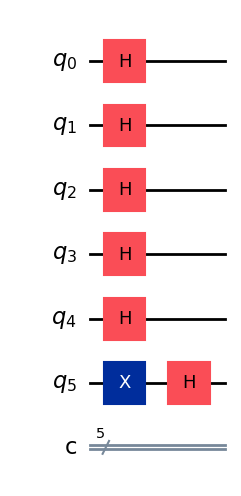

In [79]:
# 1) Prepare the equal superposition on the search register
qc.h(range(n))

# 2) Prepare the ancilla in |-> for phase kickback
qc.x(ancilla)
qc.h(ancilla)

qc.draw('mpl')

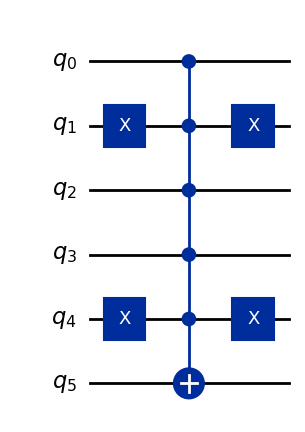

In [80]:
# Oracle Uf: apply a phase flip only on |w>
#   - flip input qubits so the marked state becomes |11111>
#   - apply a multi-controlled X onto the ancilla
#   - undo the input bit flips
oracle = QuantumCircuit(n + 1, name='Uf')
for i, bit in enumerate(w):
    if bit == '0':
        oracle.x(i)
oracle.mcx(list(range(n)), ancilla)
for i, bit in enumerate(w):
    if bit == '0':
        oracle.x(i)

oracle.draw('mpl')

/tmp/ipykernel_27/3629926178.py:9: DeprecationWarning: The class ``qiskit.circuit.library.generalized_gates.mcmt.MCMT`` is deprecated as of Qiskit 1.4. It will be removed no earlier than 3 months after the release date. Use MCMTGate instead.
  mcz_gate = MCMT('cz', n-1, 1)


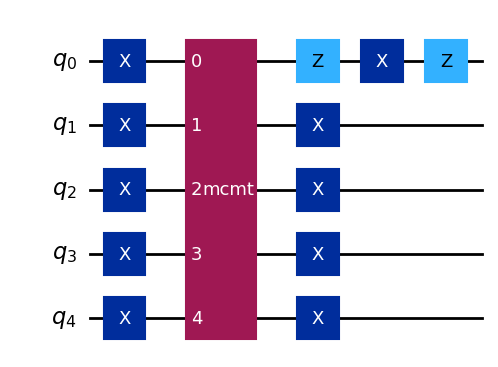

In [81]:
# First, build R0: reflection about the all-zero state |0^n> on input qubits only

# R0 is implemented by applying X gate to all n qubits, then controlled-Z gate where Z is applied to |q4>,
# followed by ZXZ gate to |q0> and X gate to |q1q2q3q4>.
R0 = QuantumCircuit(n, name='R0')
R0.x(range(n))  # X on all n qubits

# Controlled-Z: control on all qubits, Z on q4 (assuming q4 is the last qubit, index n-1)
mcz_gate = MCMT('cz', n-1, 1) 
R0.append(mcz_gate, list(range(n-1)) + [n-1])

# Then ZXZ on q0: Z, X, Z on qubit 0
R0.z(0)
R0.x(0)
R0.z(0)

# X on q1 to q4
R0.x(range(1, n))

decomposed_circuit = R0.decompose()
R0_gate = decomposed_circuit.to_gate()
R0_gate.label = 'R0'

R0.draw('mpl')

In [82]:
# Now, build Rs: reflection about the uniform superposition state, by sandwiching R0 between H gates
# Rs operates only on input qubits (not ancilla)
Rs_circuit = QuantumCircuit(n, name='Rs')
Rs_circuit.h(range(n))  # H on input qubits
Rs_circuit.append(R0_gate, range(n))  # Apply R0 on input qubits
Rs_circuit.h(range(n))  # H on input qubits
# Rs_circuit.label = 'Rs'

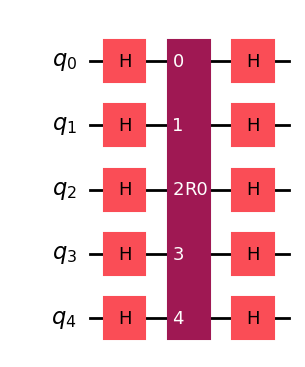

In [83]:
# Convert oracle and Rs into gates for cleaner circuit display.
Uf = oracle.to_gate()
Uf.label = 'Uf'
Rs = Rs_circuit.to_gate()
Rs.label = 'Rs'

Rs_circuit.draw('mpl')

In [84]:
# Build the full Grover circuit with 4 iterations
iterations = int((2 ** n) ** 0.5)  # Optimal number of iterations is ~sqrt(N) where N=2^n
for _ in range(iterations):
    qc.append(Uf, list(range(n + 1)))
    qc.append(Rs, list(range(n)))  # Rs only on input qubits

# Measure the search register
qc.measure(range(n), range(n))

Grover circuit:


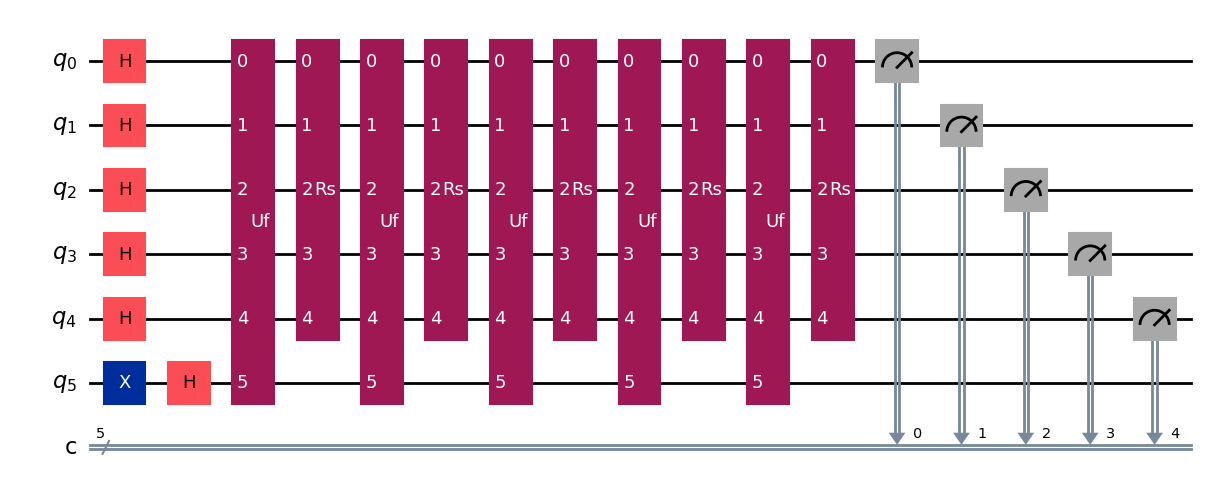

In [85]:
# Draw the full Grover circuit
print('Grover circuit:')
qc.draw('mpl')

Measurement counts:
{'10011': 2, '10001': 4, '11000': 7, '00011': 8, '00111': 3, '11110': 5, '01010': 4, '01000': 1, '01100': 9, '01001': 7, '00101': 7, '11010': 6, '10010': 3, '10101': 2, '11100': 7, '10100': 6, '10111': 2, '01111': 4, '00001': 9, '00110': 6, '01101': 848, '00010': 4, '00100': 6, '01011': 6, '11101': 5, '01110': 3, '00000': 6, '11001': 4, '11111': 3, '11011': 5, '10000': 5, '10110': 3}


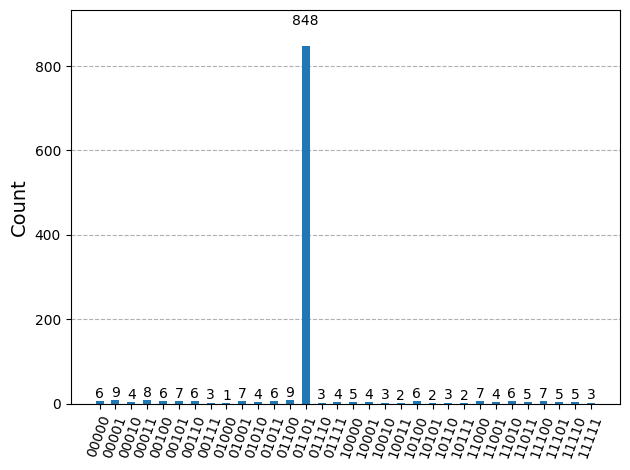

In [86]:
# Simulate the circuit and show the result
sim = AerSimulator()
qc_compiled = transpile(qc, sim)
job = sim.run(qc_compiled, shots=1000)
result = job.result()
counts = result.get_counts()
print('Measurement counts:')
print(counts)
plot_histogram(counts)

In [88]:
# check if the most common result is the marked state |w>
# reverse bit order for display since Qiskit uses little-endian convention
# Note: In Qiskit, the bitstring results are in little-endian format, meaning the least significant bit corresponds to the first qubit (q0).

most_common = max(counts, key=counts.get)
most_common_reversed = most_common[::-1]
print(f"Most common measurement result: |{most_common_reversed}>")
print(f"Marked state |w> = |{w}>")
if most_common_reversed == w:
    print("Success! The most common result is the marked state |w>.")
else:
    print("The most common result is NOT the marked state |w>. Something might be wrong.")

Most common measurement result: |10110>
Marked state |w> = |10110>
Success! The most common result is the marked state |w>.
